# Diffusion tutorial notebook

Tutorial on how to use the diffusion (random walker) functionalities in the cyanomembrane project

# Imports

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely import to_wkt
from shapely.geometry import Point

import cyanomembranes as cm

# It is convenient to define an output directory in which we save our results
(OUT := Path("output")).mkdir(exist_ok=True)

# Random generator
RNG = np.random.default_rng(seed=0)

## 1.1 Continuous diffusion without obstacles

For continuous and discrete diffusion, the process of performing in silico experiments is the same. First, the experiment is configured. For this, an **ExperimentConfig** or **ExperimentLatticeConfig** object is created, and properties determining the number of replicates, the diffusion constant, size of the simulation area, and other parameters are configured (see function description). The Config object is then used as input for the **Experiment/LatticeExperiment** object. Once the Experiment object is configured, the run method is called. As output, users obtain a **Run** object that stores simulation and summary statistics.

In [3]:
exp_config = cm.brownian.ExperimentConfig()
exp_config.replicates = 3000
exp_config.diff_coefficient = 3
exp_config

ExperimentConfig(nsteps=1000, dt=0.001, shapes=None, replicates=3000, diff_coefficient=3, start=(0.0, 0.0), dimensions=(0, 2000), coverage_dimension=None, random_start=False, aim_area=None, particle_radius=None, lattice_type=None, has_ghost=True, workers=4)

Using the mean_trajectories method, the average of all random walker trajectories will be derived. **MSD** shows the mean-squared displacement, and **Aim** specifies whether the random walker is in a previously specified area (0/1).

In [13]:
exp = cm.brownian.Experiment(exp_config)
run = exp.run()
df = run.mean_trajectories()
df

,Time,X,Y,MSD,Aim,traj_id
0,0.000,0.000000,0.000000,0.000000,4.819681e-310,1499.5
1,0.001,-0.003705,0.001789,0.011869,4.819679e-310,1499.5
2,0.002,-0.002571,0.000328,0.023357,0.000000e+00,1499.5
3,0.003,-0.001036,0.001326,0.034567,0.000000e+00,1499.5
4,0.004,-0.003072,-0.000143,0.045658,-4.198548e-03,1499.5
...,...,...,...,...,...,...
995,0.995,0.020392,-0.013994,11.974998,1.337480e-02,1499.5
996,0.996,0.022822,-0.015044,11.983242,1.454964e-02,1499.5
997,0.997,0.021566,-0.012923,12.000901,1.407662e-02,1499.5
998,0.998,0.020555,-0.014197,12.017384,1.221221e-02,1499.5


The diffusion coefficient is 3.0074852933716762
The diffusion coefficient (power law) is 11.967231468442055, alpha is 0.9971856350881059


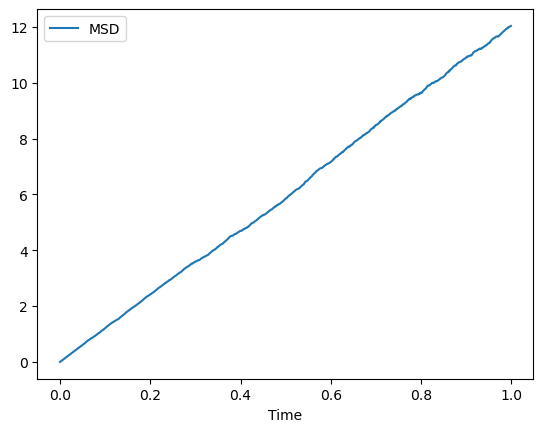

In [5]:
df.plot(x="Time", y="MSD")
print(f"The diffusion coefficient is {run.get_mean_diff_coefficients()[1]}")
# note the diffusion coefficient in the power law is not normalized to the dimension
print(f"The diffusion coefficient (power law) is {run.get_mean_diff_coefficients_pw()[1]}, alpha is {run.get_mean_diff_coefficients_pw()[2]}")

## 1.2 Lattice diffusion without obstacles

For the lattice diffusion experiment, the entire simulation area and the polygons placed on it will be rasterized (standard resolution is 1:1). The config attribute'ghosts' indicates whether the polygons (obstacles) include their ghost (copy) to mimic periodic boundary conditions. store_history specifies whether the Run object should include the X and Y coordinates of each random walker at all time steps.

In [14]:
expl_config = cm.brownian_lattice.ExperimentLatticeConfig()
expl_config.replicates = 5000
expl_config.diff_coefficient = 3
expl_config.has_ghost = False
expl_config.store_history = True

In [15]:

exp = cm.brownian_lattice.ExperimentLattice(expl_config)
run = exp.run()
df = run.mean_trajectories()

/home/tim/Gitrepos/cyanomembranes/.pixi/envs/default/lib/python3.13/site-packages/rasterio/features.py:336: ShapeSkipWarning: Invalid or empty shape {'type': 'GeometryCollection', 'geometries': []} at index 0 will not be rasterized.
  warnings.warn(


  0%|          | 0/1000 [00:00<?, ?it/s]

When store_history is set to True we can access the random walk of each replicate 

In [16]:
run.trajectories[0].data

,Time,Replicate,Y,X,MSD,Active
0,0.000000,0,2000,2000,0,1
1,0.083333,0,1999,2000,1,1
2,0.166667,0,1999,1999,2,1
3,0.250000,0,2000,1999,1,1
4,0.333333,0,2000,2000,0,1
...,...,...,...,...,...,...
996,83.000000,0,1993,1967,1138,1
997,83.083336,0,1993,1966,1205,1
998,83.166672,0,1992,1966,1220,1
999,83.250000,0,1992,1965,1289,1


The diffusion coefficient is 2.9906423091888428
The diffusion coefficient (power law) is 11.925667480587546, alpha is 1.001844882965088


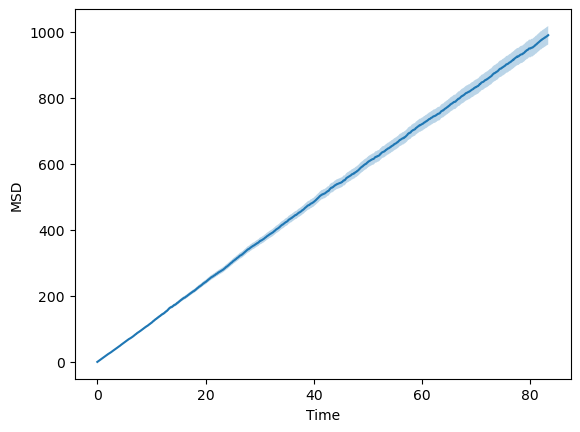

In [17]:
print(f"The diffusion coefficient is {run.get_mean_diff_coefficients()[1]}")
# note the diffusion coefficient in the power law is not normalized to the dimension
print(f"The diffusion coefficient (power law) is {run.get_mean_diff_coefficients_pw()[1]}, alpha is {run.get_mean_diff_coefficients_pw()[2]}")

fig, ax = plt.subplots()
ax.plot(df["Time"], df["MSD"])

ax.fill_between(
    df["Time"],
    df["MSD_ci_low"],
    df["MSD_ci_high"],
    alpha=0.3
)

ax.set_xlabel("Time")
ax.set_ylabel("MSD")
plt.show()

## 1.3 Diffusion without obstacles but with aim area

It is possible to record whether a random walker stays or leaves an aim area. For this, we need to specify the aim area as a shapely polygon and assign it to the Config object's aim_area property. Additionally, we can locate the starting positions of the random walkers using the starting position property

In [19]:

aim_area = Point(1000,1000).buffer(2)
exp_config = cm.brownian.ExperimentConfig()
exp_config.replicates = 100
exp_config.diff_coefficient = 3
exp_config.aim_area = aim_area
exp_config.start = (1000, 1000)

exp = cm.brownian.Experiment(exp_config)
run = exp.run()
df = run.mean_trajectories()

For both continuous and lattice diffusion, the Run object includes functionality to visualize random walker trajectories on the simulation surface.

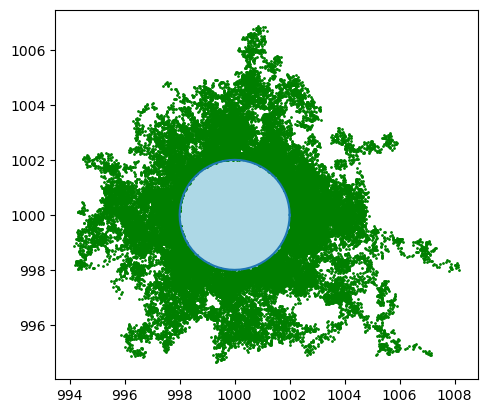

In [20]:
fig, ax = plt.subplots()
ax.plot(*aim_area.exterior.xy)
run.plot_run(ax=ax, aim_area=True)
ax.set_aspect("equal")

Using the "Aim" column of the mean_trajectory dataframe, we can create a plot showing the fraction of random walkers in the aim area at each time step.

[]

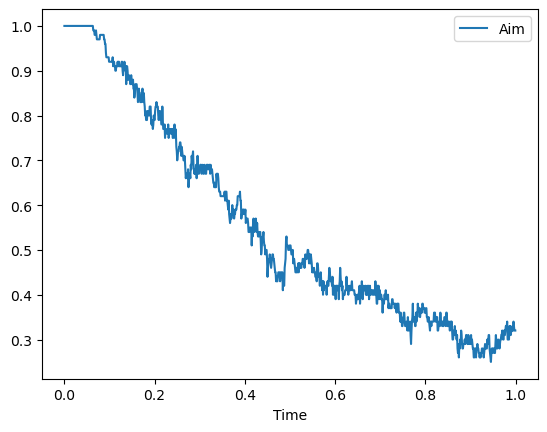

In [21]:
df.plot(x = "Time", y= "Aim").plot()

## Lattice diffusion without obstacles but with aim area

In [ ]:

aim_area = Point(1000,1000).buffer(20)
expl_config = cm.brownian_lattice.ExperimentLatticeConfig()
expl_config.replicates = 1000
expl_config.diff_coefficient = 3
expl_config.aim_area = aim_area
expl_config.start = (1000, 1000)
expl_config.has_ghost = False
expl_config.store_history = True

exp = cm.brownian_lattice.ExperimentLattice(expl_config)
run = exp.run()
df = run.mean_trajectories()

In [ ]:
fig, ax = plt.subplots()
ax.plot(*aim_area.exterior.xy)
run.plot_run(ax=ax, aim_area=True)
#ax.imshow(exp.aim_mask)
ax.set_aspect("equal")
ax.set_ylim(750,1250)
ax.set_xlim(750,1250)

In [ ]:
fig, ax = plt.subplots()
ax.plot(df["Time"], df["Aim"])

ax.fill_between(
    df["Time"],
    df["Aim_ci_low"],
    df["Aim_ci_high"],
    alpha=0.3
)

ax.set_xlabel("Time")
ax.set_ylabel("% in Aim")
plt.show()

### Lattice diffusion with chosen obstacles



In [ ]:
ring1 = Point(1000,1000).buffer(100)
ring2 = Point(1000,1000).buffer(90)
chosen_obstacle = ring1.difference(ring2)
shapes = [chosen_obstacle]
config_lattice = cm.brownian_lattice.ExperimentLatticeConfig()
config_lattice.shapes = shapes
config_lattice.nsteps = 100_000
config_lattice.dimensions = (0, 2000)
config_lattice.replicates = 3000
config_lattice.diff_coefficient = 100
config_lattice.particle_radius = None
config_lattice.start = (1000,1000)
#config_lattice.random_start = True
config_lattice.has_ghost = False
config_lattice.store_history = True
config_lattice.save_every=100
config_lattice.chosen_obstacles_by_area = chosen_obstacle.area
config_lattice.steady_state_chosen_obstacle = True
#config_lattice.start_area = ring2

exp = cm.brownian_lattice.ExperimentLattice(config_lattice)
run = exp.run()
df = run.mean_trajectories()

In [ ]:
if run.hits is not None:
    fig, axes = plt.subplots(1, 4, figsize=(15,40))
else:
    fig, axes = plt.subplots(1, 3, figsize=(10,30))
# fig, axes = plt.subplots(1,1)
# axes = [axes]
run.plot_run(ax=axes[0])
axes[0].set_xlim(800,1200)
axes[0].set_ylim(800,1200)
#axes[0].scatter(2947-2000, 2928-2000, s=20)

axes[1].plot(df["Time"], df["Active"])
axes[1].fill_between(
    df["Time"],
    df["Active_ci_low"],
    df["Active_ci_high"],
    alpha=0.3
)

axes[1].set_xlabel("Time")
axes[1].set_ylabel("Active %")
axes[1].set_title("Survival")

fi_times = run.fpt["FirstInactiveTime"]
fi_times.plot.hist(ax = axes[2], bins=150, alpha=0.8, legend=False)
fi_val = fi_times.dropna().to_numpy()
median = np.median(fi_val)
q25 = np.percentile(fi_val, 25)
q75 = np.percentile(fi_val, 75)
iqr = q75 - q25
print(iqr)
axes[2].set_xlabel("First Hitting Time")
axes[2].set_title("First Hitting Time distribution")

summary_text = f"Median = {median:.2f}\nIQR = {iqr:.2f}"

axes[2].text(
    0.95, 0.95,
    summary_text,
    transform = axes[2].transAxes,
    verticalalignment = "top",
    horizontalalignment = "right",
    bbox = {"boxstyle": "round,pad=0.5", "facecolor": "white"}
)

if run.hits is not None:
    hits = run.hits.drop("Time", axis=1)
    time = run.hits["Time"]
    dt = time.diff().iloc[1]
    N_particles = len(hits.columns)
    hits_per_int = hits.sum(axis=1)
    flux = hits_per_int/dt
    rate_constant = flux/N_particles
    axes[3].plot(time, hits_per_int)
    axes[3].set_xlabel("Time")
    axes[3].set_ylabel("Rate constant")

for ax in axes:
    ax.set_box_aspect(1)

plt.tight_layout()

In [ ]:
hits.sum(axis=1)

In [ ]:
# shapes = [
#     Point(RNG.uniform(0,2000), RNG.uniform(0,2000)).buffer(20)
#     for _ in range(150)
# ]

start_area =  Point(1000,1000).buffer(100)

config_lattice = cm.brownian_lattice.ExperimentLatticeConfig()
config_lattice.shapes = shapes
config_lattice.nsteps = 100_000
config_lattice.dimensions = (0, 2000)
config_lattice.replicates = 3000
config_lattice.diff_coefficient = 1
config_lattice.particle_radius = None
config_lattice.random_start = True
config_lattice.has_ghost = False
config_lattice.store_history = True
config_lattice.save_every=1000
config_lattice.chosen_obstacles_by_area = shapes[0].area
config_lattice.steady_state_chosen_obstacle = True
config_lattice.start_area = start_area



exp = cm.brownian_lattice.ExperimentLattice(config_lattice)
run = exp.run()
df = run.mean_trajectories()

In [ ]:
if run.hits is not None:
    fig, axes = plt.subplots(1, 4, figsize=(15,40))
else:
    fig, axes = plt.subplots(1, 3, figsize=(10,30))
run.plot_run(ax=axes[0])
#axes[0].set_xlim(500,1500)
#axes[0].set_ylim(500,1500)

df.plot(ax = axes[1], x="Time", y="Active")
axes[1].set_ylabel("Active %")
axes[1].set_title("Survival")

fi_times = run.fpt["FirstInactiveTime"]
fi_times.plot.hist(ax = axes[2], bins=150, alpha=0.8, legend=False)
fi_val = fi_times.dropna().to_numpy()
median = np.median(fi_val)
q25 = np.percentile(fi_val, 25)
q75 = np.percentile(fi_val, 75)
iqr = q75 - q25
print(iqr)
axes[2].set_xlabel("First Hitting Time")
axes[2].set_title("First Hitting Time distribution")

summary_text = f"Median = {median:.2f}\nIQR = {iqr:.2f}"

axes[2].text(
    0.95, 0.95,
    summary_text,
    transform = axes[2].transAxes,
    verticalalignment = "top",
    horizontalalignment = "right",
    bbox = {"boxstyle": "round,pad=0.5", "facecolor": "white"}
)

if run.hits is not None:
    hits = run.hits.drop("Time", axis=1)
    time = run.hits["Time"]
    dt = time.diff().iloc[1]
    N_particles = len(hits.columns)
    hits_per_int = hits.sum(axis=1)
    flux = hits_per_int/dt
    rate_constant = flux/N_particles
    axes[3].plot(time, rate_constant)
    axes[3].set_xlabel("Time")
    axes[3].set_ylabel("Rate constant")

for ax in axes:
    ax.set_box_aspect(1)

plt.tight_layout()

## Diffusion with obstacles

In [ ]:
shapes = [
    Point(RNG.uniform(0,5000), RNG.uniform(0,5000)).buffer(RNG.uniform(0,100))
    for _ in range(1500)
]

In [ ]:
config = cm.brownian.ExperimentConfig()
config.shapes = shapes
config.replicates = 3000
config.dimensions = (0,5000)
config.diff_coefficient = 1e4
config.random_start = True
config.particle_radius = 20

exp = cm.brownian.Experiment(config)
run = exp.run()

In [ ]:
exp.coverage

In [ ]:
def plot_result(shapes, res):
    fig,axes = plt.subplots(1,2)
    for p in shapes:
        axes[0].plot(*p.exterior.xy, c='blue', lw=0.8)
    res.plot_run(ax=axes[0])
    axes[0].set_aspect("equal")


    for p in shapes:
        axes[1].plot(*p.exterior.xy, c='blue', lw=0.8)
    res.plot_run(ax=axes[1])
    axes[1].set_aspect("equal")
    axes[1].set_xlim(3000, 4000)
    axes[1].set_ylim(0,1000)
    plt.show()

plot_result(config.shapes, run)

## Lattice diffusion with obstacles

In [ ]:
shapes = [
    Point(RNG.uniform(0,5000), RNG.uniform(0,5000)).buffer(RNG.uniform(0,100))
    for _ in range(1500)
]

config_lattice = cm.brownian_lattice.ExperimentLatticeConfig()
config_lattice.shapes = shapes
config_lattice.nsteps = 10_000
config_lattice.dimensions = (0, 5000)
config_lattice.replicates = 3000
config_lattice.diff_coefficient = 1e4
config_lattice.particle_radius = 20
config_lattice.random_start = True
config_lattice.has_ghost = False
config_lattice.store_history = True

exp = cm.brownian_lattice.ExperimentLattice(config_lattice)
run = exp.run()

In [ ]:
def plot_result_lattice(res):
    fig,axes = plt.subplots(1,2)
    res.plot_run(ax=axes[0])
    axes[0].set_aspect("equal")

    res.plot_run(ax=axes[1])
    axes[1].set_aspect("equal")
    axes[1].set_xlim(3000, 4000)
    axes[1].set_ylim(0,1000)
    plt.show()

plot_result_lattice(run)

## Diffusion with obstacles and aim area

In [ ]:
aim_area = Point(2500, 2500).buffer(500)

config = cm.brownian.ExperimentConfig()
config.shapes = shapes
config.replicates = 1000
config.dimensions = (0,5000)
config.diff_coefficient = 1e4
config.random_start = True
config.particle_radius = 20
config.aim_area = aim_area

exp = cm.brownian.Experiment(config)
run = exp.run()

fig,ax = plt.subplots()
for p in shapes:
    ax.plot(*p.exterior.xy, c='blue', lw=0.8)
run.plot_run(ax=ax, aim_area=True)
ax.plot(*aim_area.exterior.xy, c="red")
ax.set_aspect("equal")


## Lattice diffusion with obstacles and aim area

In [ ]:
aim_area = Point(2500, 2500).buffer(500)

config_lattice = cm.brownian_lattice.ExperimentLatticeConfig()
config_lattice.shapes = shapes
config_lattice.replicates = 1000
config_lattice.nsteps = 10_000
config_lattice.dimensions = (0,5000)
config_lattice.diff_coefficient = 1e4
config_lattice.random_start = True
config_lattice.particle_radius = 20
config_lattice.aim_area = aim_area
config_lattice.has_ghost = False
config_lattice.store_history = True

exp = cm.brownian_lattice.ExperimentLattice(config_lattice)
run = exp.run()

fig,ax = plt.subplots()
run.plot_run(ax=ax, aim_area=True)
ax.plot(*aim_area.exterior.xy, c="red")
ax.set_aspect("equal")


## Ensemble of diffusion experiments with obstacles

In [ ]:
out_dir = Path("output/diffusion")
out_dir.mkdir(parents=True, exist_ok=True)

for i in range(6):
    shapes = [
        Point(RNG.uniform(0,5000), RNG.uniform(0,5000)).buffer(RNG.uniform(0,100))
        for _ in range(1500)
    ]

    file_path = out_dir / f"shapes_{i}.wkt"

    with file_path.open("w") as f:
        for p in shapes:
            f.write(to_wkt(p) + "\n")

    print(f"Saved {file_path.name}")

In [ ]:
file_lst = list(out_dir.glob("*.wkt"))

config = cm.brownian.ExperimentConfig()
config.shapes = shapes
config.replicates = 3000
config.dimensions = (0,5000)
config.diff_coefficient = 1e4
config.random_start = True
config.particle_radius = 20

ens_exp = cm.brownian.EnsembleExperiment(file_lst, config)
ens_run = ens_exp.run()

In [ ]:
model, A, alpha = ens_run.get_mean_diff_coefficients_pw()
mean_over_runs_df = ens_run.mean_over_runs()

fig, ax = plt.subplots()
mean_over_runs_df.plot(x="Time", y="MSD", ax=ax)
ax.plot(mean_over_runs_df["Time"], A*mean_over_runs_df["Time"]**alpha) # plot power law
plt.show()
print(f"The diffusion coefficient is {ens_run.get_mean_diff_coefficients()[1]}")
print(f"The diffusion coefficient (power law) is {A}, alpha is {alpha}")

In [ ]:
def plot_result(shapes, res):
    fig,axes = plt.subplots(1,3, figsize=(10,30) )
    for p in shapes:
        axes[0].plot(*p.exterior.xy, c='blue', lw=0.8)
    res.plot_run(ax=axes[0])
    axes[0].set_box_aspect(1)


    for p in shapes:
        axes[1].plot(*p.exterior.xy, c='blue', lw=0.8)
    res.plot_run(ax=axes[1])
    axes[1].set_box_aspect(1)
    axes[1].set_xlim(3000, 4000)
    axes[1].set_ylim(0,1000)

    axes2 = res.mean_trajectories().plot(x="Time", y="MSD", ax=axes[2], legend=False)
    axes2.set_box_aspect(1)
    axes2.set_xlim(0, 1.5)
    axes2.set_ylim(0,31000)

    fig.tight_layout()
    plt.show()

    print(f"The diffusion coefficient is {res.get_mean_diff_coefficients()[1]}")
    print(f"The diffusion coefficient (power law) is {res.get_mean_diff_coefficients_pw()[1]}, alpha is {ens_run.get_mean_diff_coefficients_pw()[2]}")

for idx, f in enumerate(ens_exp.file_paths):
    shapes = cm.geo_utils.readwkt(f)
    run = ens_run.runs[idx]
    plot_result(shapes, run)

In [ ]:
ens_run.get_mean_coverage()

In [ ]:
file_lst = list(out_dir.glob("*.wkt"))

config_lattice = cm.brownian_lattice.ExperimentLatticeConfig()
config_lattice.shapes = shapes
config_lattice.replicates = 5000
config_lattice.nsteps = 50_000
config_lattice.dimensions = (0,5000)
config_lattice.diff_coefficient = 1e4
config_lattice.random_start = True
config_lattice.particle_radius = 20
config_lattice.has_ghost = False
config_lattice.store_history = True
config_lattice.workers = 6
config_lattice.save_every = 50

ens_exp = cm.brownian_lattice.EnsembleExperimentLattice(file_lst, config_lattice)
ens_run = ens_exp.run()

In [ ]:
ens_run.mean_over_runs()

In [ ]:
model, A, alpha = ens_run.get_mean_diff_coefficients_pw()
mean_over_runs_df = ens_run.mean_over_runs()

fig, ax = plt.subplots()
ax.plot(mean_over_runs_df["Time"],mean_over_runs_df["MSD"])
ax.fill_between(
    mean_over_runs_df["Time"],
    mean_over_runs_df["MSD_std"],
    mean_over_runs_df["MSD_ci_high"],
    alpha=0.3
)
ax.plot(mean_over_runs_df["Time"], A*mean_over_runs_df["Time"]**alpha) # plot power law
plt.show()
print(f"The diffusion coefficient is {ens_run.get_mean_diff_coefficients()[1]}")
print(f"The diffusion coefficient (power law) is {A}, alpha is {alpha}")

In [ ]:
def plot_result(shapes, res):
    fig,axes = plt.subplots(1,3, figsize=(10,30) )
    res.plot_run(ax=axes[0])
    axes[0].set_box_aspect(1)

    res.plot_run(ax=axes[1])
    axes[1].set_box_aspect(1)
    axes[1].set_xlim(3000, 4000)
    axes[1].set_ylim(0,1000)

    axes[2].plot(mean_over_runs_df["Time"],mean_over_runs_df["MSD"])
    axes[2].fill_between(
        mean_over_runs_df["Time"],
        mean_over_runs_df["MSD_ci_low"],
        mean_over_runs_df["MSD_ci_high"],
        alpha=0.3
    )
    axes[2].set_box_aspect(1)
    axes[2].set_xlim(0, 1.5)
    axes[2].set_ylim(0,31000)

    fig.tight_layout()
    plt.show()

    print(f"The diffusion coefficient is {res.get_mean_diff_coefficients()[1]}")
    print(f"The diffusion coefficient (power law) is {res.get_mean_diff_coefficients_pw()[1]}, alpha is {ens_run.get_mean_diff_coefficients_pw()[2]}")

for idx, f in enumerate(ens_exp.file_paths):
    shapes = cm.geo_utils.readwkt(f)
    run = ens_run.runs[idx]
    plot_result(shapes, run)

In [ ]:
ens_run.get_mean_coverage()

In [ ]:
out_dir = Path("output/diffusion2")
out_dir.mkdir(parents=True, exist_ok=True)

for i in range(5):
    shapes = [
        Point(RNG.uniform(0,5000), RNG.uniform(0,5000)).buffer(RNG.uniform(0,100))
        for _ in range(550)
    ] + [Point(RNG.uniform(0,5000), RNG.uniform(0,5000)).buffer(55) for _ in range(90)]

    file_path = out_dir / f"shapes_aim_area_{i}.wkt"

    with file_path.open("w") as f:
        for p in shapes:
            f.write(to_wkt(p) + "\n")

    print(f"Saved {file_path.name}")

chosen_obstacle_area = Point(0,0).buffer(55).area

In [ ]:
file_lst = list(out_dir.glob("*.wkt"))

config_lattice = cm.brownian_lattice.ExperimentLatticeConfig()
config_lattice.shapes = shapes
config_lattice.replicates = 3000
config_lattice.nsteps = 20_000
config_lattice.dimensions = (0,5000)
config_lattice.diff_coefficient = 1e4
config_lattice.random_start = True
config_lattice.particle_radius = 5
config_lattice.has_ghost = False
config_lattice.store_history = True
config_lattice.workers = 6
config_lattice.save_every = 10
config_lattice.chosen_obstacles_by_area = chosen_obstacle_area
config_lattice.steady_state_chosen_obstacle = True
config_lattice.rng = RNG


ens_exp = cm.brownian_lattice.EnsembleExperimentLattice(file_lst, config_lattice)
ens_run = ens_exp.run()

In [ ]:
ens_run.runs[4].hits.drop("Time",axis=1).sum(axis=1).plot()

In [ ]:
ens_run.get_mean_hits().plot("Time","Hits")

In [ ]:
ens_run.get_mean_hits().iloc[250:]["Hits"].hist(bins=12)

In [ ]:
ens_run.get_mean_hits().iloc[250:]

## Test start area for Ensemble

In [ ]:
out_dir = Path("output/diffusion2")
out_dir.mkdir(parents=True, exist_ok=True)

for i in range(5):
    shapes = [
        Point(RNG.uniform(0,5000), RNG.uniform(0,5000)).buffer(100)
        for _ in range(10)
    ] + [Point(RNG.uniform(0,5000), RNG.uniform(0,5000)).buffer(55) for _ in range(10)]

    file_path = out_dir / f"shapes_start_area_{i}.wkt"

    with file_path.open("w") as f:
        for p in shapes:
            f.write(to_wkt(p) + "\n")

    print(f"Saved {file_path.name}")

start_size = Point(0,0).buffer(55).area

In [ ]:
from shapely.geometry import box

config_lattice = cm.brownian_lattice.ExperimentLatticeConfig()
config_lattice.shapes = shapes
config_lattice.replicates = 1000
config_lattice.nsteps = 50_000
config_lattice.dimensions = (0,5000)
config_lattice.diff_coefficient = 1e4
config_lattice.random_start = True
config_lattice.particle_radius = 5
config_lattice.has_ghost = False
config_lattice.store_history = True
config_lattice.workers = 6
config_lattice.save_every = 50
config_lattice.start_area_by_size = (start_size, 100, box(0,0,5000,5000))

ens_exp = cm.brownian_lattice.EnsembleExperimentLattice(file_lst, config_lattice)
ens_run = ens_exp.run()

In [ ]:
for i in ens_run.runs:
    fig,ax = plt.subplots()
    i.plot_run(ax=ax)
    ax.set_xlim(0,5000)
    ax.set_ylim(0,5000)

# Obstacle size effect

In [ ]:
def create_circles(start_circle, factor=2, iterations=9):
    current_area = start_circle.area
    current_number = 1
    circle_dict = {current_number: [start_circle]}
    for i in range(iterations):
        current_number *= factor
        current_area = current_area/factor
        radius = np.sqrt(current_area/np.pi)
        circle_lst = []
        for j in range(current_number):
            circle_lst.append(Point(0,0).buffer(radius))
        circle_dict[current_number] = circle_lst
    return circle_dict

start_circle = Point(0,0).buffer(2000, resolution=1000)

circle_dict = create_circles(start_circle)
    

In [ ]:
for k,v in circle_dict.items():
    area = sum([i.area for i in v])
    print(f"{k}: {area}")

In [ ]:
out_dir = Path("output/diffusion3")
out_dir.mkdir(parents=True, exist_ok=True)

In [ ]:

for k in circle_dict.keys():
    for d in range(10):
        world, placed_polygons, not_placed, ghosts = cm.geo_utils.placement_routine(
            circle_dict[k],
            dimensions=[5000, 5000],
            step_size=30,
            rotation_angle=360,
            max_iter_placement=600,
            )
        
        polygons = world + list(np.array(ghosts).ravel())
        
        file_path = out_dir/f"circles_{k}-{d}.wkt"
        
        with file_path.open("w") as f:
            for p in polygons:
                f.write(to_wkt(p) + "\n")
                
        print(f"Saved {file_path.name}")

    


In [ ]:
import gc

cfg = cm.brownian_lattice.ExperimentLatticeConfig()
cfg.replicates = 3000
cfg.nsteps = 500_000
cfg.diff_coefficient = 1e4 
cfg.particle_radius = 5
cfg.dimensions = (0, 5000)
cfg.random_start = True
cfg.has_ghost = True
cfg.store_history = False
cfg.save_every = 3000
cfg.workers = 10

fig, ax = plt.subplots()
for k in list(circle_dict.keys()):
    print(k)
    file_lst = list(out_dir.glob(f"circles_{k}-*.wkt"))
    ens_exp = cm.brownian_lattice.EnsembleExperimentLattice(file_lst, cfg)
    ens_run = ens_exp.run()
    del ens_exp
    gc.collect()

    df = ens_run.get_mean_diff_coefficients_dist().iloc[1:]
    
    ax.plot(np.sqrt(df["MSD"]), df["D_dist"], label=f"#Circles: {k}")

    ax.fill_between(
         np.sqrt(df["MSD"]),
         df["D_dist_ci_low"],
         df["D_dist_ci_high"],
         alpha=0.3
    )
plt.legend()
plt.show()
plt.close(fig)
